<a href="https://colab.research.google.com/github/janberryjam/ccs8-githubrepositoryactivity/blob/main/DataVisualizationNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Imports and Loading**

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Model selection & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import (
    StandardScaler,
    label_binarize
)


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

# Save model
import joblib

In [ ]:
# Load dataset
url = "https://github.com/janberryjam/ccs8-githubrepositoryactivity/raw/refs/heads/main/XGirls_CleanData.xlsx"
df = pd.read_excel(url)

# Check first rows
df.head()

,Course,Schedule,Previous_Qualification_Grade,Admission_Grade,Displaced_Status,Scholarship_Holder_Status,Financial_Risk,Age,PC1_1st_Sem,PC2_1st_Sem,PC1_2nd_Sem,PC2_2nd_Sem,Performance_Change,Target
0,1,1,-0.804841,0.022229,1,0,1,0,-3.784635,0.682756,-3.918683,0.216433,-0.134048,0
1,9,1,2.076819,1.071926,1,0,2,0,-0.004781,-0.801936,0.127368,-0.774739,0.132149,2
2,4,1,-0.804841,-0.150419,1,0,2,0,-2.561306,0.929043,-2.557660,0.642023,0.003646,0
3,13,1,-0.804841,-0.509526,1,0,1,0,0.165394,-0.652383,0.296103,-0.410020,0.130708,2
4,2,0,-2.473171,1.002867,0,0,1,2,0.034917,-0.407856,0.076946,-0.716695,0.042029,2


**Set Up**

In [ ]:
features    = [c for c in df.columns if c != 'Target']
numerical   = ['Previous_Qualification_Grade', 'Admission_Grade', 'Age',
                'PC1_1st_Sem', 'PC2_1st_Sem', 'PC1_2nd_Sem', 'PC2_2nd_Sem',
                'Performance_Change', 'Financial_Risk']
categorical = ['Course', 'Schedule', 'Displaced_Status', 'Scholarship_Holder_Status']

target_labels = {0: 'Graduate', 1: 'Enrolled', 2: 'Dropout'}
df['Target_Label'] = df['Target'].map(target_labels)
palette = ['#4C72B0', '#DD8452', '#55A868']

# **STEP 1: VISUALIZING THE RAW DATA (EDA)**

**Target Class Distribution**

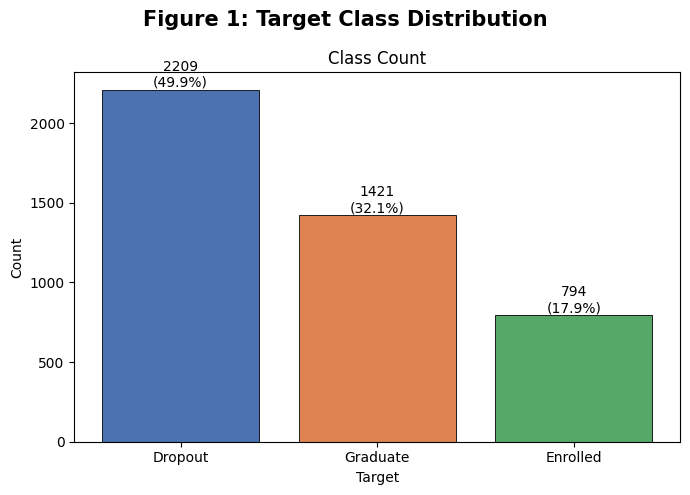

In [ ]:
target_labels = {0: 'Graduate', 1: 'Enrolled', 2: 'Dropout'}
palette = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle("Figure 1: Target Class Distribution", fontsize=15, fontweight='bold')

counts = df['Target'].map(target_labels).value_counts()
total = counts.sum()

ax.bar(counts.index, counts.values, color=palette, edgecolor='black', linewidth=0.6)
ax.set_title("Class Count")
ax.set_xlabel("Target")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    pct = v / total * 100
    ax.text(i, v + 20, f'{v}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Distribution of All Numerical Features**

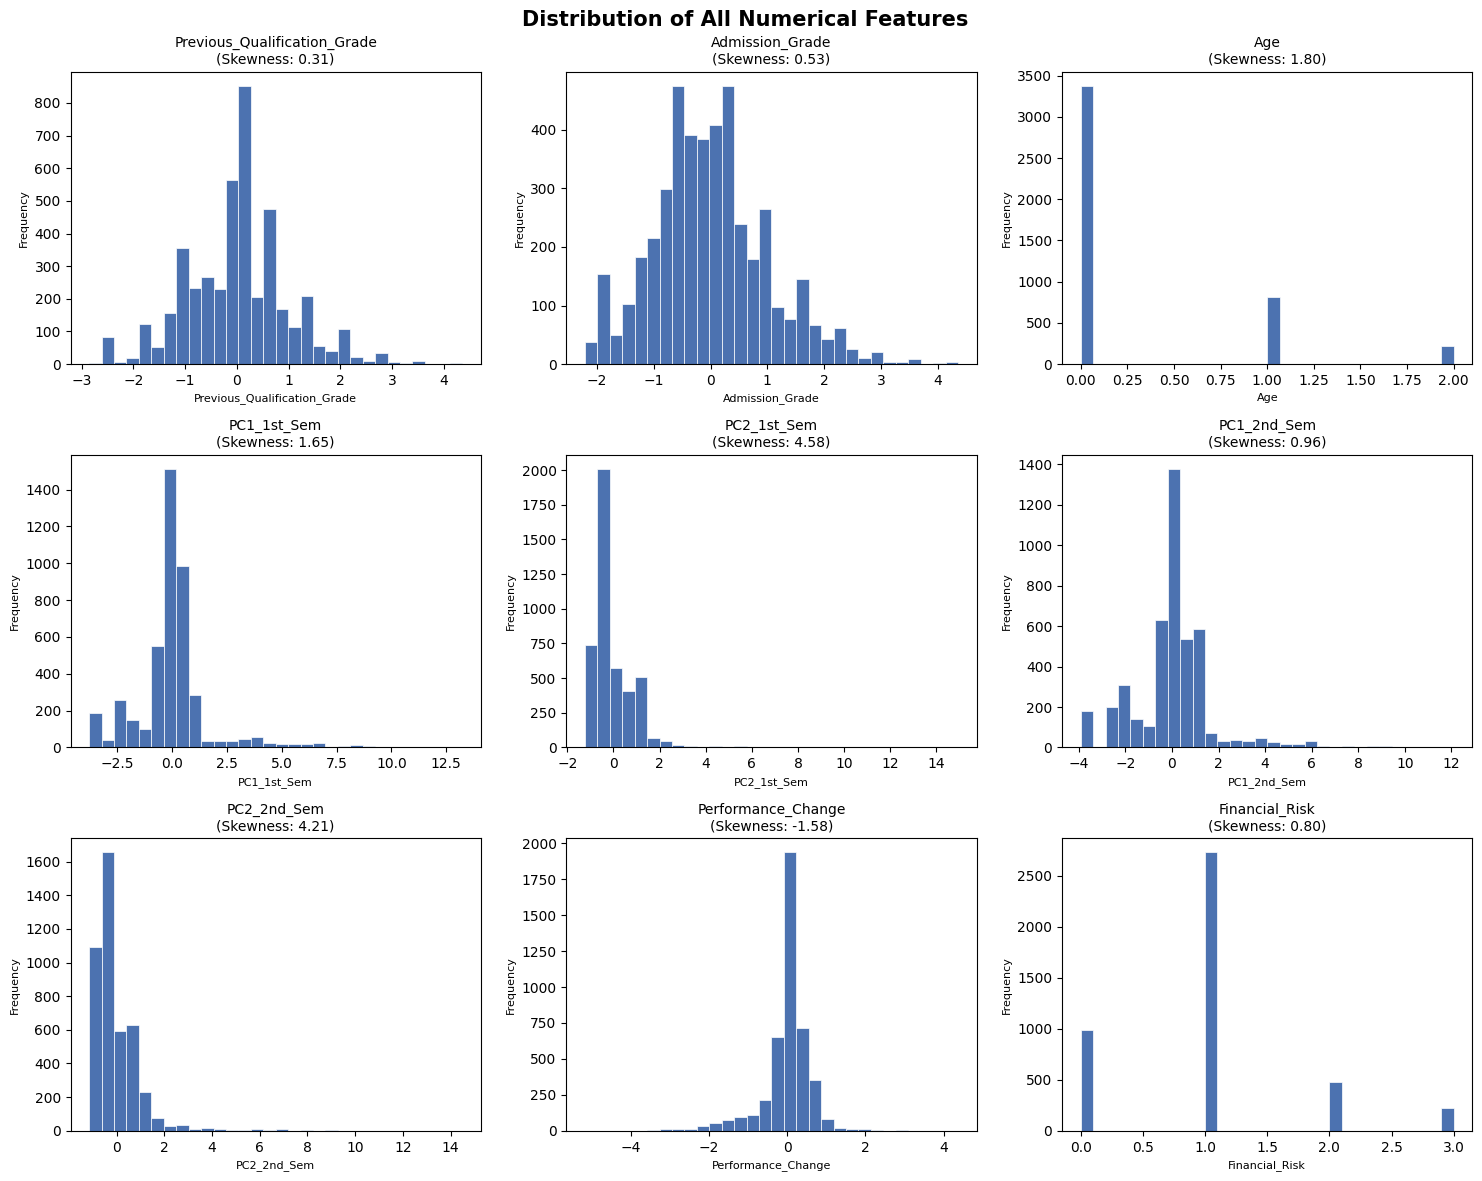

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Distribution of All Numerical Features", fontsize=15, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(numerical):
    skew = df[col].skew()
    axes[i].hist(df[col], bins=30, color='#4C72B0', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f"{col}\n(Skewness: {skew:.2f})", fontsize=10)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel("Frequency", fontsize=8)
plt.tight_layout()
plt.show()


**Box Plot of All Numerical Features**

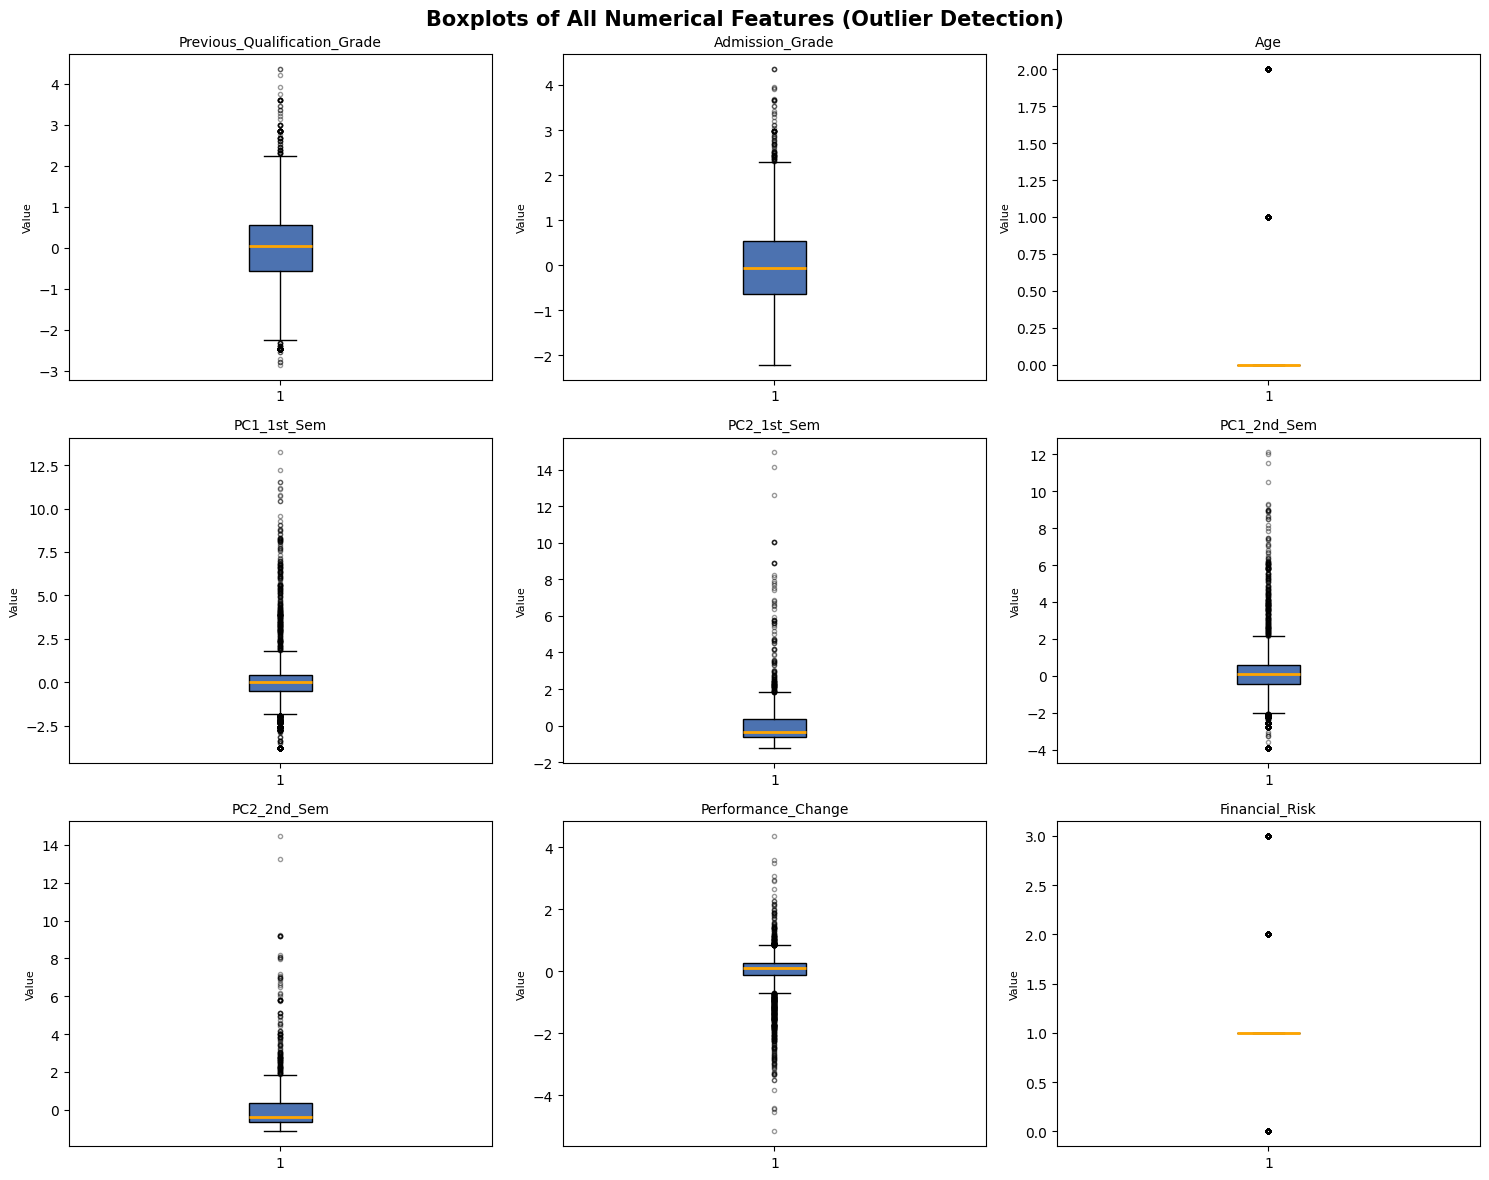

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Boxplots of All Numerical Features (Outlier Detection)",
             fontsize=15, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(numerical):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', color='black'),
                    medianprops=dict(color='orange', linewidth=2),
                    flierprops=dict(marker='o', color='red', alpha=0.4, markersize=3))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value", fontsize=8)
plt.tight_layout()
plt.show()

**Distribution of Categorical Features**

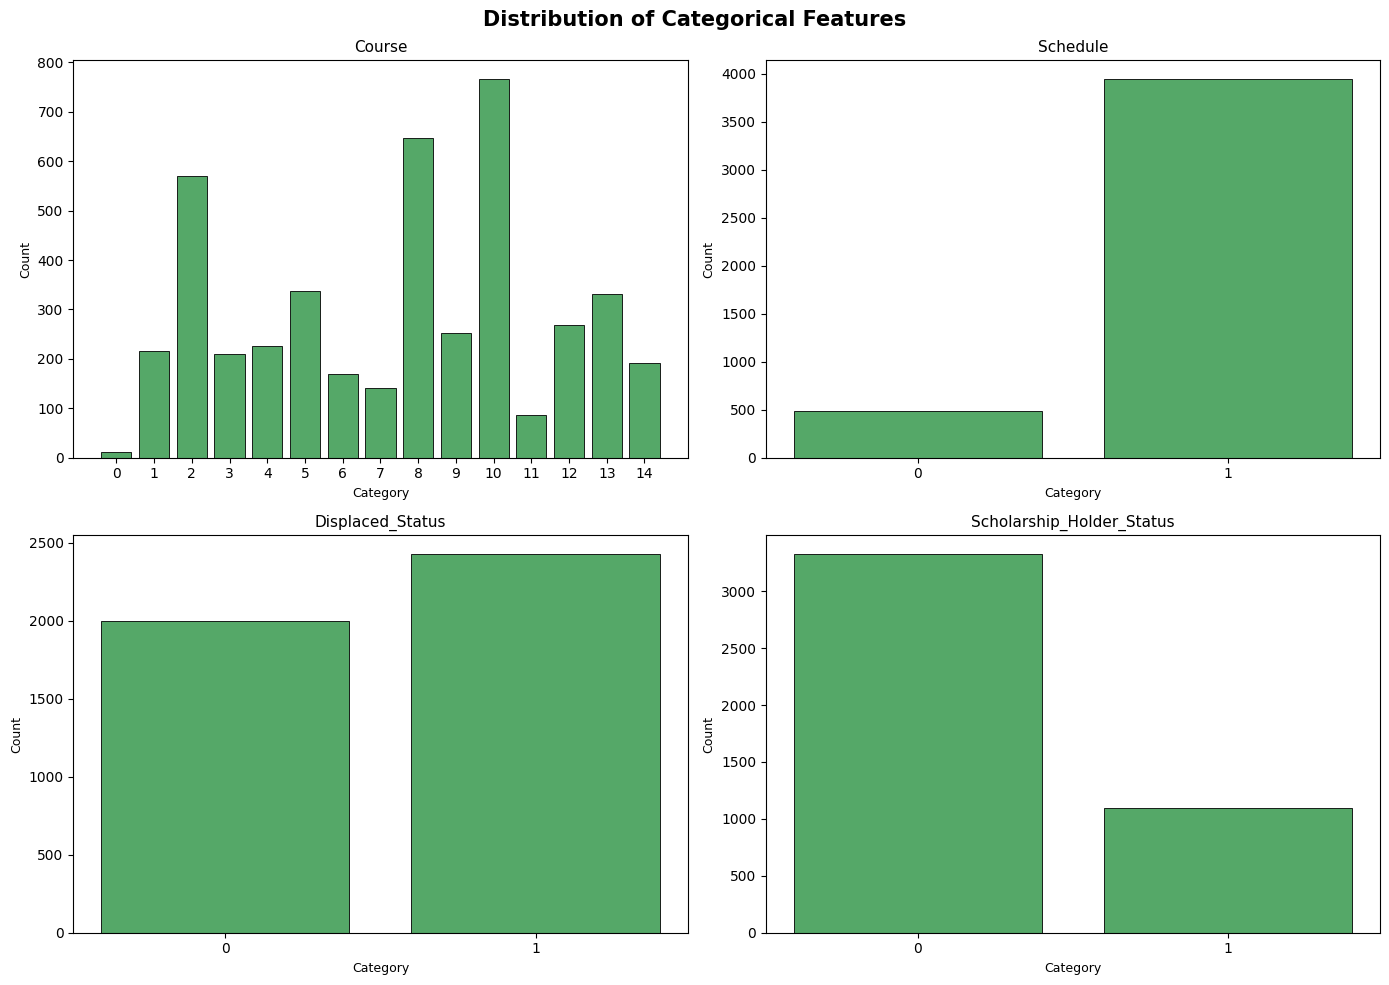

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distribution of Categorical Features",
             fontsize=15, fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(categorical):
    counts_col = df[col].value_counts().sort_index()
    axes[i].bar(counts_col.index.astype(str), counts_col.values,
                color='#55A868', edgecolor='black', linewidth=0.6)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Category", fontsize=9)
    axes[i].set_ylabel("Count", fontsize=9)
plt.tight_layout()
plt.show()


**Feature Correlation Heatmap**

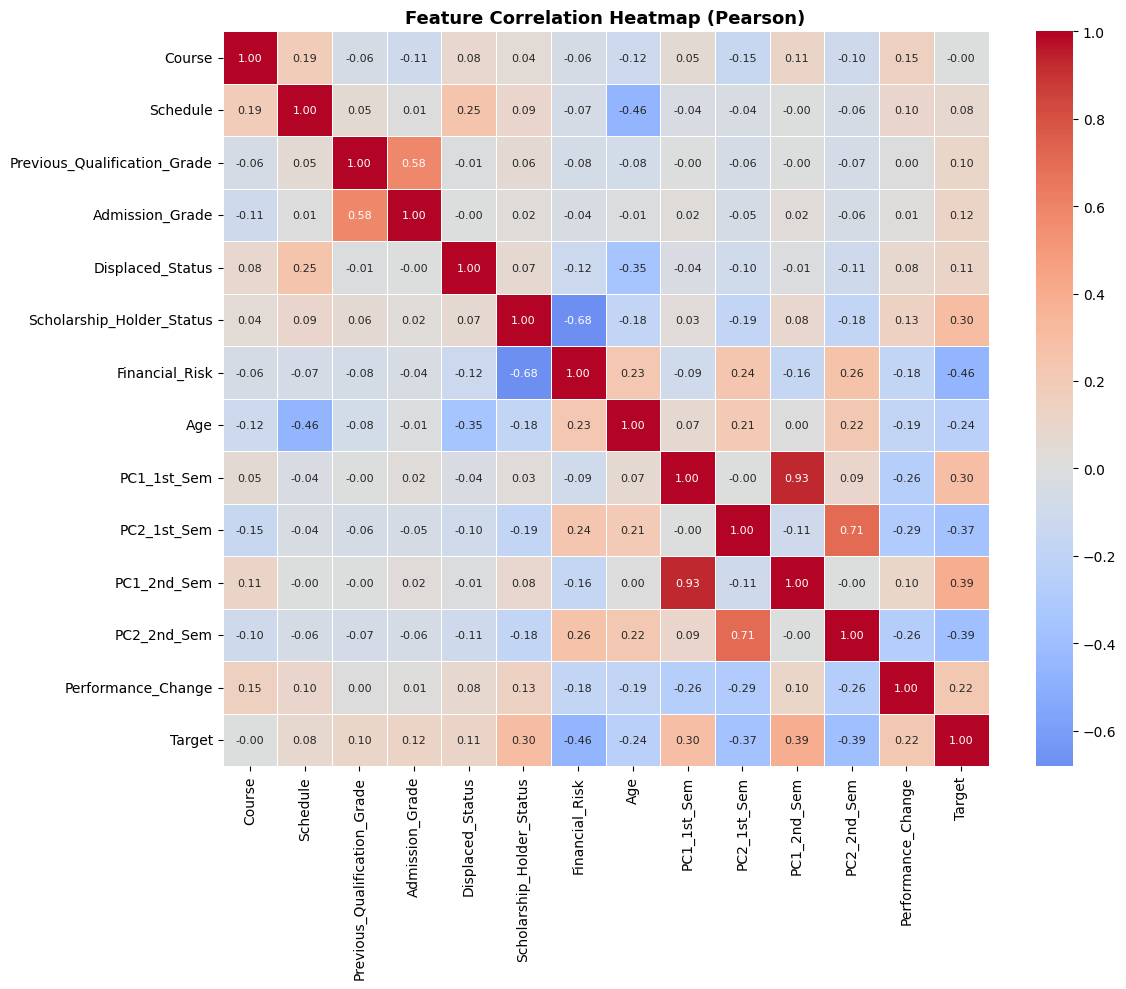

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
features = [c for c in df.columns if c != 'Target_Label']
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title("Feature Correlation Heatmap (Pearson)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


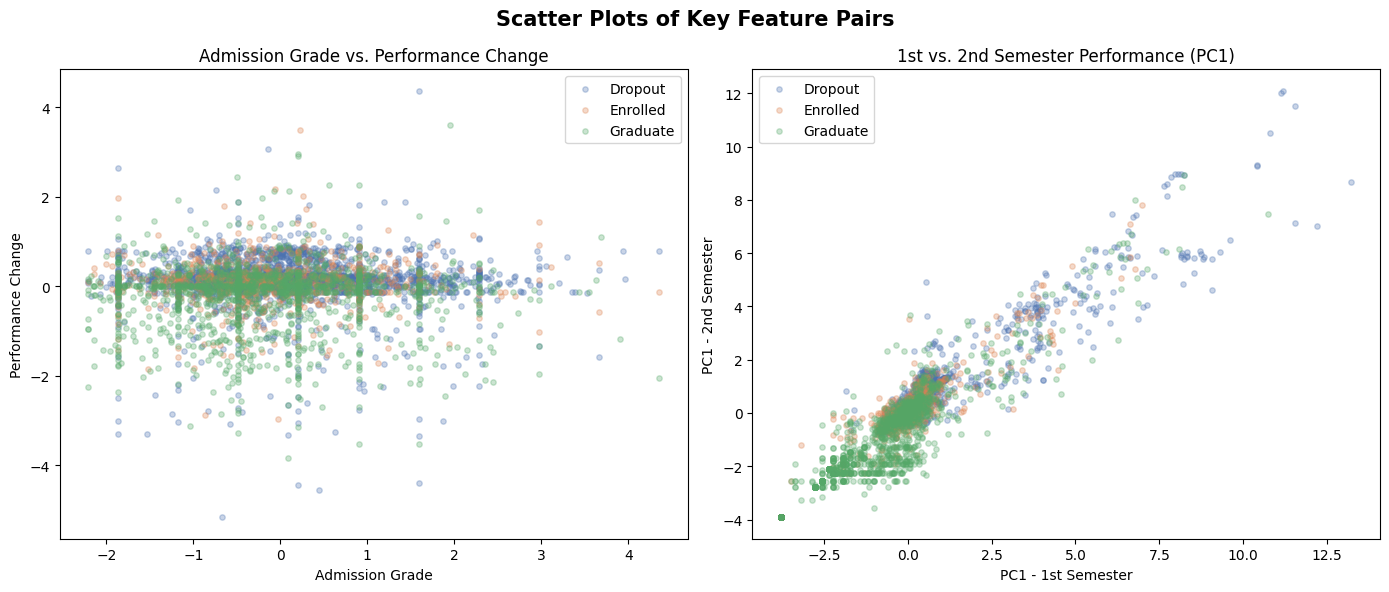

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Scatter Plots of Key Feature Pairs",
             fontsize=15, fontweight='bold')

for j, (label, group) in enumerate(df.groupby('Target_Label')):
    axes[0].scatter(group['Admission_Grade'], group['Performance_Change'],
                    alpha=0.3, s=15, label=label, color=palette[j])
axes[0].set_xlabel("Admission Grade")
axes[0].set_ylabel("Performance Change")
axes[0].set_title("Admission Grade vs. Performance Change")
axes[0].legend()

for j, (label, group) in enumerate(df.groupby('Target_Label')):
    axes[1].scatter(group['PC1_1st_Sem'], group['PC1_2nd_Sem'],
                    alpha=0.3, s=15, label=label, color=palette[j])
axes[1].set_xlabel("PC1 - 1st Semester")
axes[1].set_ylabel("PC1 - 2nd Semester")
axes[1].set_title("1st vs. 2nd Semester Performance (PC1)")
axes[1].legend()

plt.tight_layout()
plt.show()

**Feature Importance Analysis **

Random Forest Accuracy: 0.7389830508474576

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.75      0.76       284
           1       0.45      0.33      0.38       159
           2       0.79      0.88      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.65      0.66       885
weighted avg       0.72      0.74      0.73       885

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Random Forest Accuracy: 0.7502824858757062


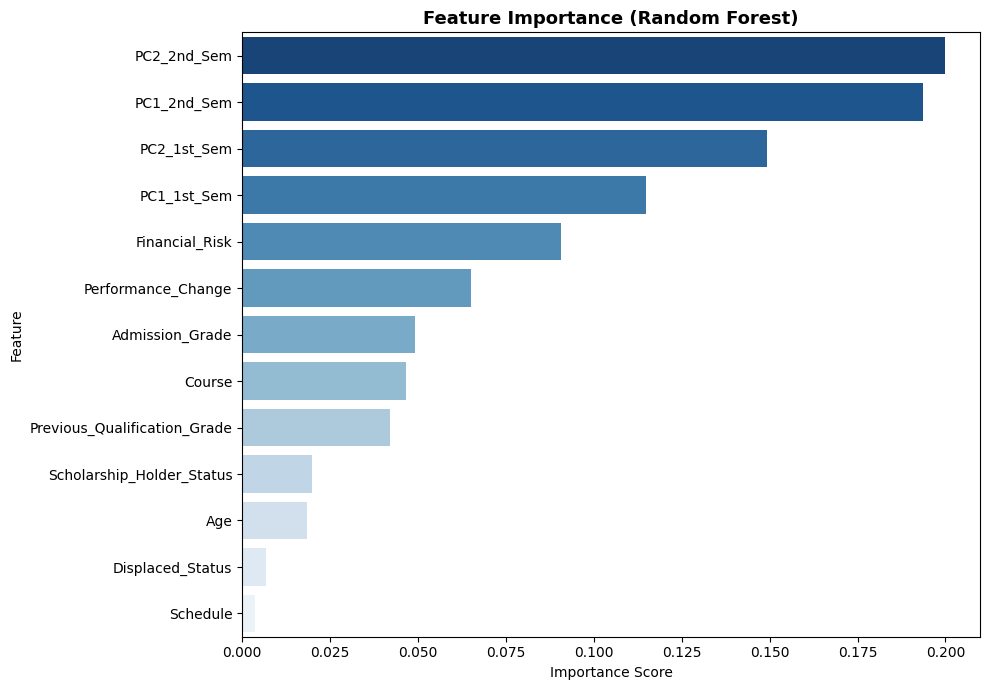

In [ ]:
#Model Training
# Train-test split (80/20)

df = df.drop('Target_Label', axis=1, errors='ignore')
X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))


feature_importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='Blues_r', legend=False)
plt.title("Feature Importance (Random Forest)", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


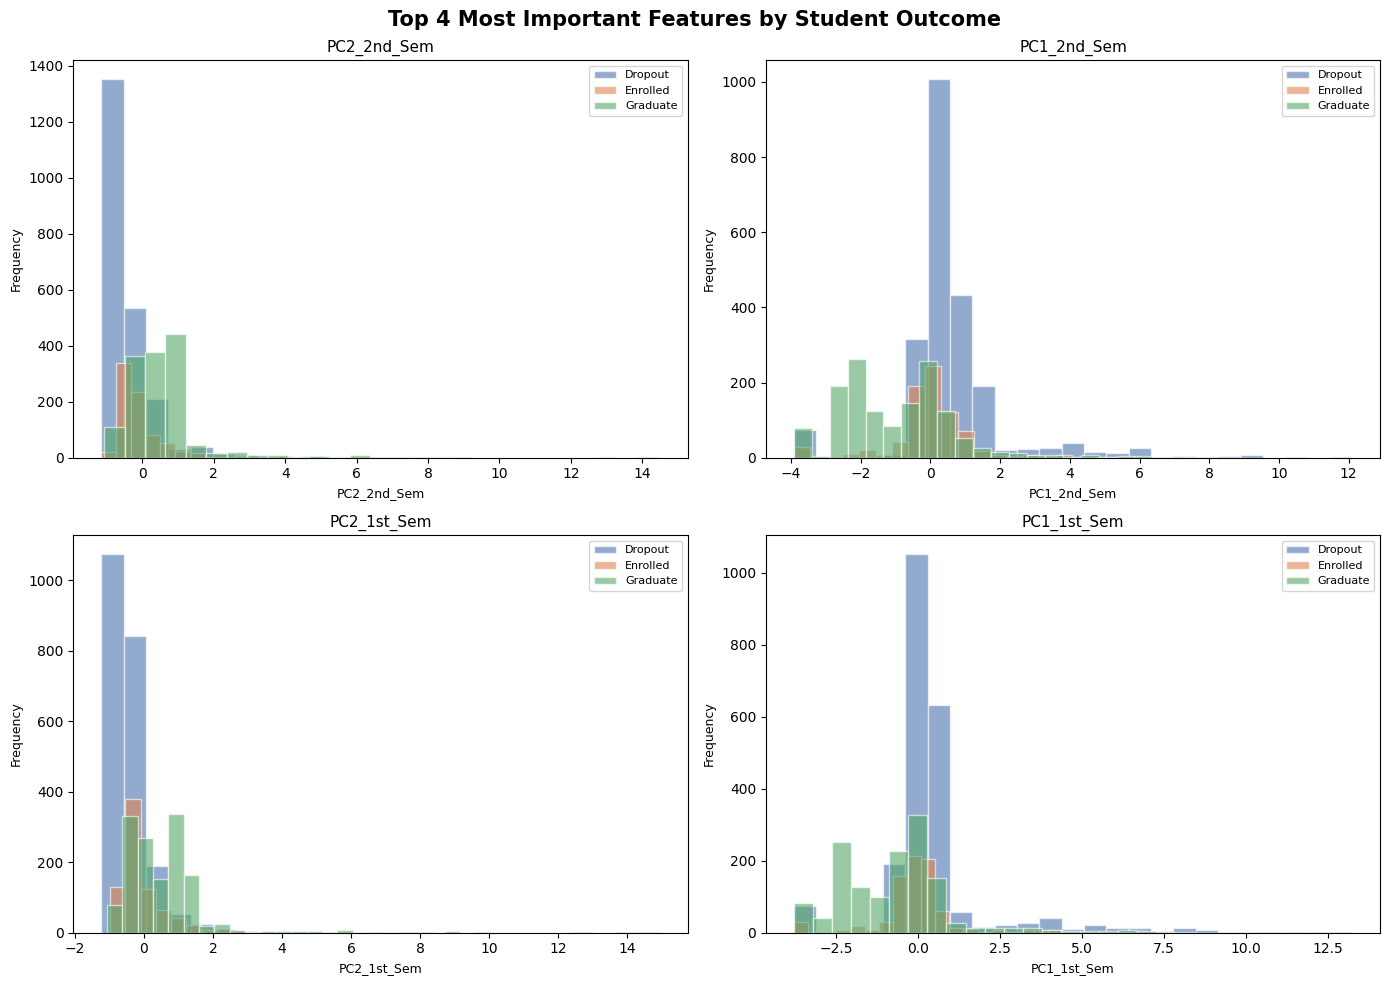

Top 4 features used in Figure 6: ['PC2_2nd_Sem', 'PC1_2nd_Sem', 'PC2_1st_Sem', 'PC1_1st_Sem']


In [ ]:
top4_features = importance_df.head(4)['Feature'].tolist()

target_labels = {0: 'Graduate', 1: 'Enrolled', 2: 'Dropout'}
df['Target_Label'] = df['Target'].map(target_labels)
palette = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Top 4 Most Important Features by Student Outcome",
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(top4_features):
    for j, (label, group) in enumerate(df.groupby('Target_Label')):
        axes[i].hist(group[col], bins=25, alpha=0.6, label=label,
                     color=palette[j], edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Frequency", fontsize=9)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Top 4 features used in Figure 6:", top4_features)

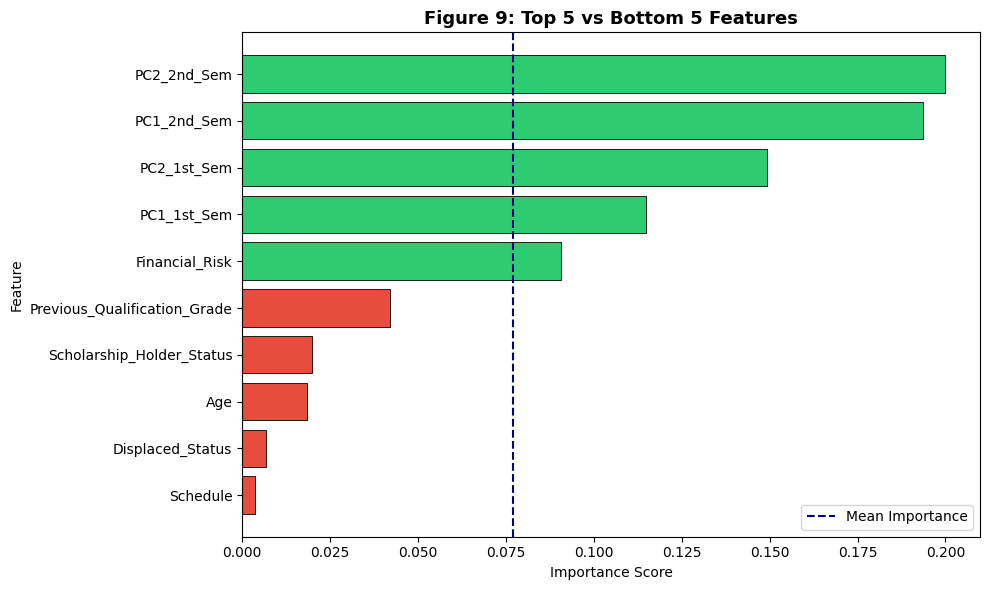

In [ ]:
top5 = importance_df.head(5)
bottom5 = importance_df.tail(5)
combined = pd.concat([top5, bottom5])

colors = ['#2ecc71' if i < 5 else '#e74c3c' for i in range(len(combined))]

plt.figure(figsize=(10, 6))
bars = plt.barh(combined['Feature'], combined['Importance'], color=colors, edgecolor='black', linewidth=0.6)
plt.axvline(x=importance_df['Importance'].mean(), color='navy', linestyle='--', label='Mean Importance')
plt.title("Top 5 vs Bottom 5 Features", fontsize=13, fontweight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

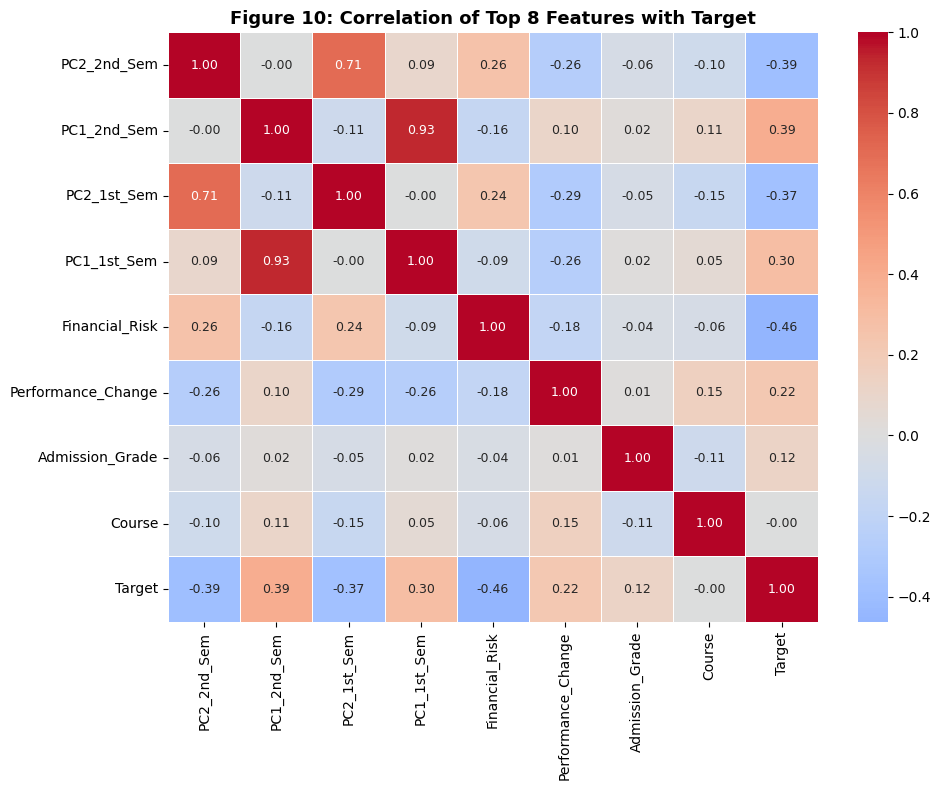

In [ ]:
top_features = importance_df.head(8)['Feature'].tolist() + ['Target']
corr_top = df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title("Correlation of Top 8 Features with Target", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



In [ ]:
print("\nFeature Importance Ranking:")
print(importance_df.to_string(index=False))


Feature Importance Ranking:
                     Feature  Importance
                 PC2_2nd_Sem    0.199838
                 PC1_2nd_Sem    0.193612
                 PC2_1st_Sem    0.149196
                 PC1_1st_Sem    0.114810
              Financial_Risk    0.090663
          Performance_Change    0.065094
             Admission_Grade    0.049276
                      Course    0.046509
Previous_Qualification_Grade    0.042136
   Scholarship_Holder_Status    0.019789
                         Age    0.018550
            Displaced_Status    0.006807
                    Schedule    0.003720


**Evaluate Model Performance Visually**

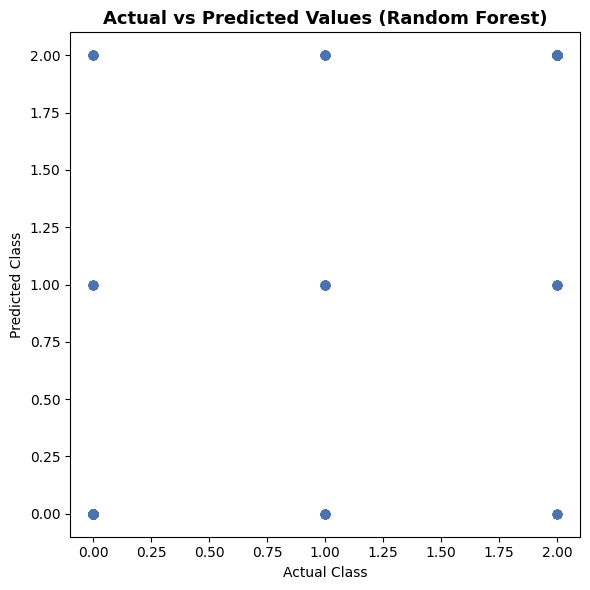

In [ ]:
y_pred = best_rf.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#4C72B0')
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("Actual vs Predicted Values (Random Forest)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

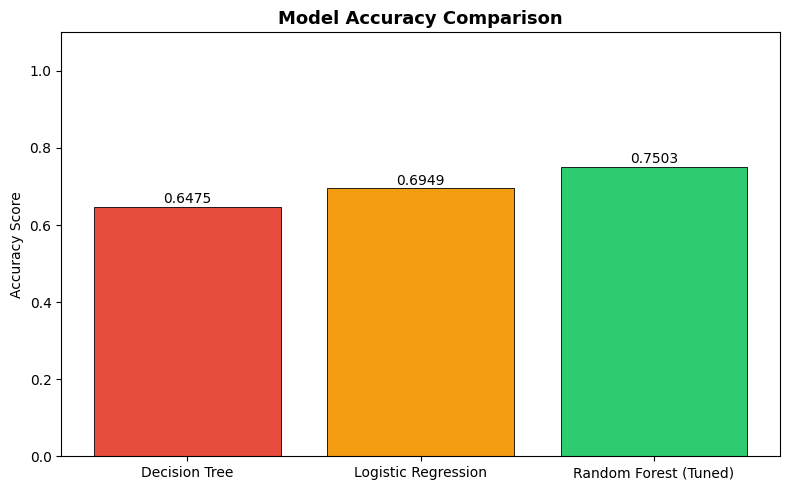

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

models = ['Decision Tree', 'Logistic Regression', 'Random Forest (Tuned)']
accuracies = [
    accuracy_score(y_test, dt_model.predict(X_test)),
    accuracy_score(y_test, lr_model.predict(X_test)),
    accuracy_score(y_test, y_pred)
]

colors = ['#e74c3c', '#f39c12', '#2ecc71']
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=0.6)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison", fontsize=13, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


**Risidual Analysis**

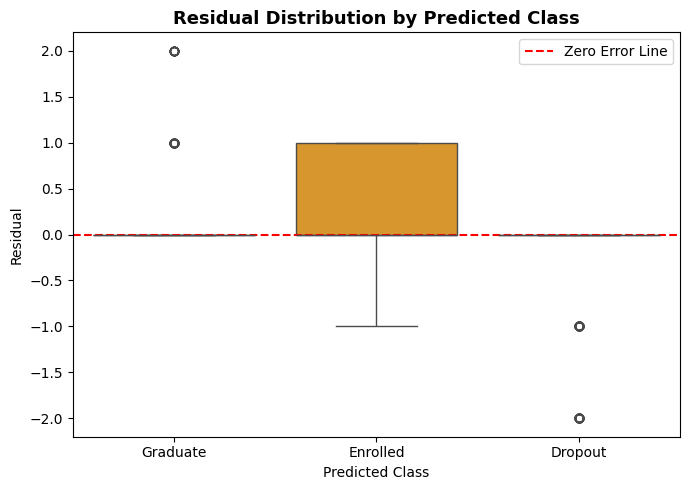


Residual Summary:
Mean Residual   : -0.0768  (closer to 0 = better)
Std of Residuals: 0.6817
Max Error       : 2
Min Error       : -2


In [ ]:
residual_df = pd.DataFrame({
    'Predicted': y_pred,
    'Residual': residuals
})

plt.figure(figsize=(7, 5))
sns.boxplot(x='Predicted', y='Residual', data=residual_df,
            hue='Predicted', palette=['#2ecc71', '#f39c12', '#e74c3c'], legend=False)
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.xticks([0, 1, 2], ['Graduate', 'Enrolled', 'Dropout'])
plt.title("Residual Distribution by Predicted Class", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Class")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

print("\nResidual Summary:")
print(f"Mean Residual   : {residuals.mean():.4f}  (closer to 0 = better)")
print(f"Std of Residuals: {residuals.std():.4f}")
print(f"Max Error       : {residuals.max()}")
print(f"Min Error       : {residuals.min()}")

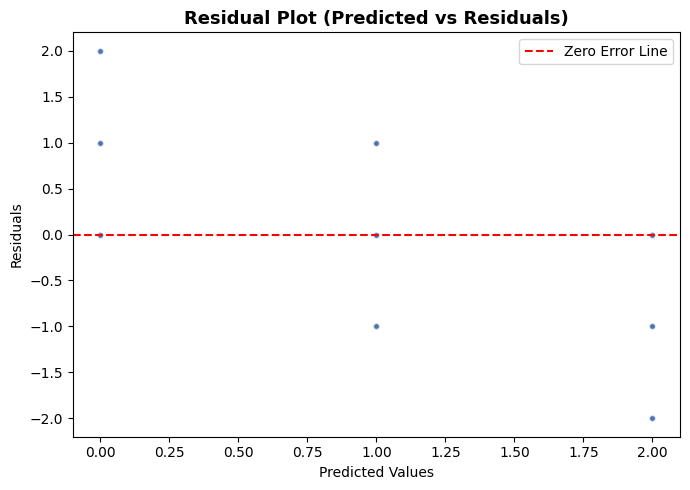

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='#4C72B0', edgecolor='white', s=20)
plt.axhline(0, color='red', linestyle='--', label='Zero Error Line')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Predicted vs Residuals)", fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

**Visualizing Classification Performance**

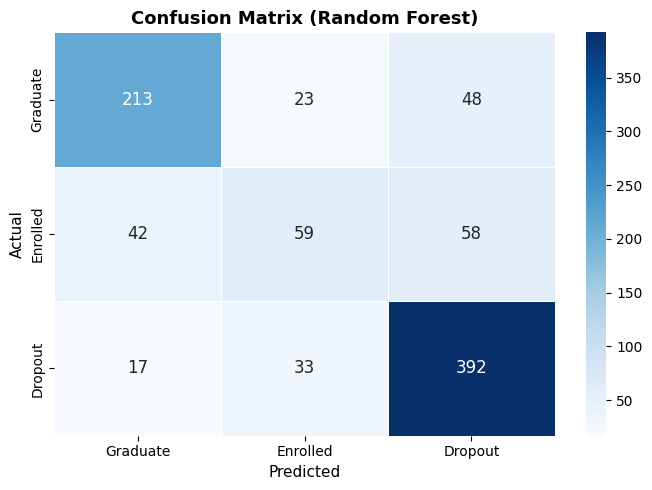


Classification Report:
              precision    recall  f1-score   support

    Graduate       0.78      0.75      0.77       284
    Enrolled       0.51      0.37      0.43       159
     Dropout       0.79      0.89      0.83       442

    accuracy                           0.75       885
   macro avg       0.69      0.67      0.68       885
weighted avg       0.74      0.75      0.74       885



In [ ]:
y_pred = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
labels = ['Graduate', 'Enrolled', 'Dropout']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, annot_kws={'size': 12})
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("Actual", fontsize=11)
plt.title("Confusion Matrix (Random Forest)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=labels))

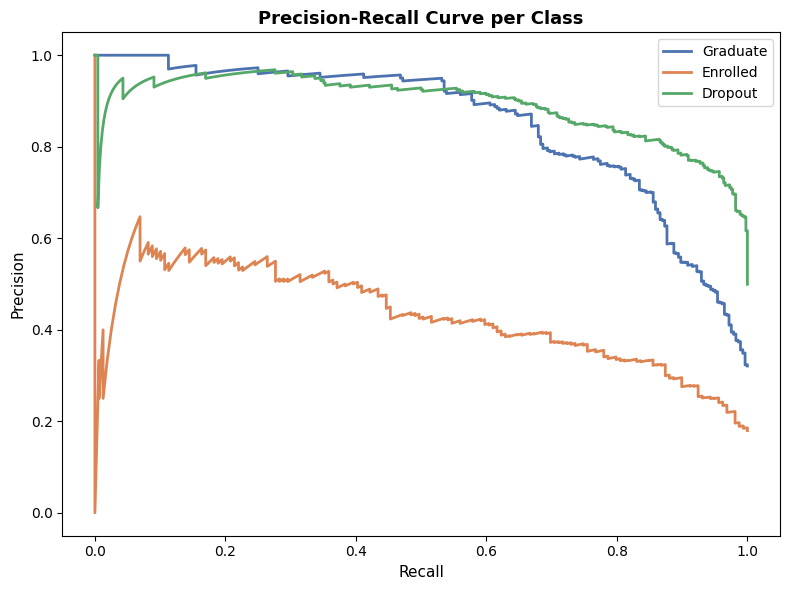

In [ ]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_prob = best_rf.predict_proba(X_test)

colors_pr = ['#4C72B0', '#DD8452', '#55A868']

plt.figure(figsize=(8, 6))
for i, (label, color) in enumerate(zip(labels, colors_pr)):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(recall, precision, label=f"{label}", color=color, linewidth=2)

plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.title("Precision-Recall Curve per Class", fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()